# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  12.8M      0 --:--:--  0:01:08 --:--:-- 17.8M


In [3]:
!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [4]:
!gunzip SUSY.csv.gz

The data is provided as a comma separated file.

In [6]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [4]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [5]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [6]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [7]:
FeatureNames

['M_Delta_R',
 'M_TR_2',
 'M_R',
 'S_R',
 'axial_MET',
 'R',
 'MET_rel',
 'dPhi_r_b',
 'cos_theta_r1',
 'MT2']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [9]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [10]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [11]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


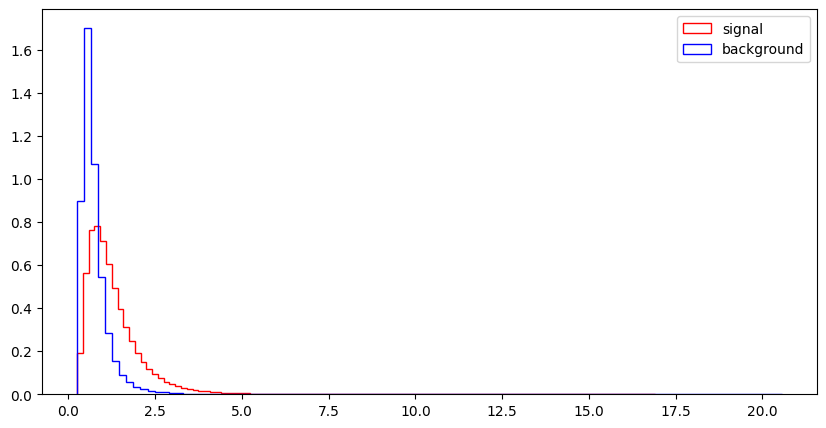

l_1_eta


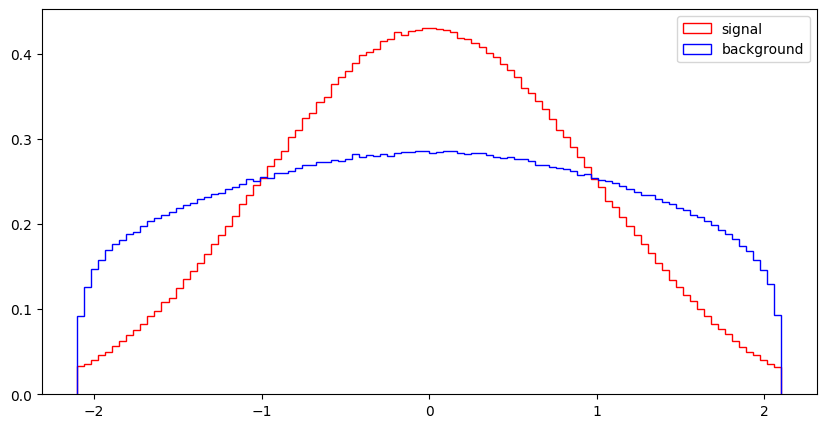

l_1_phi


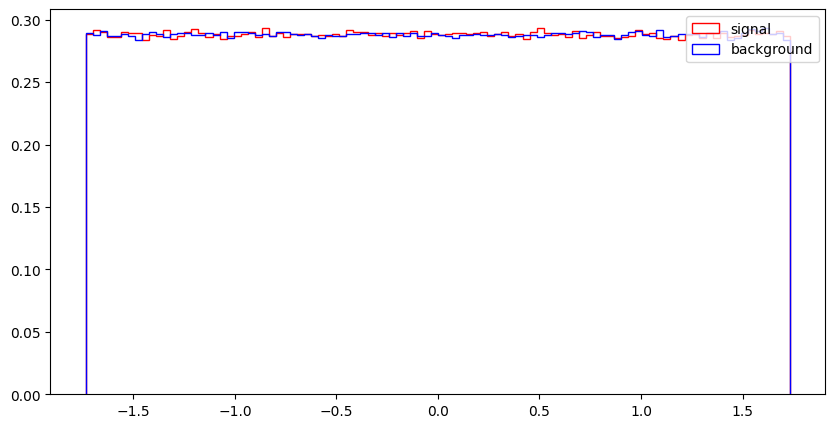

l_2_pT


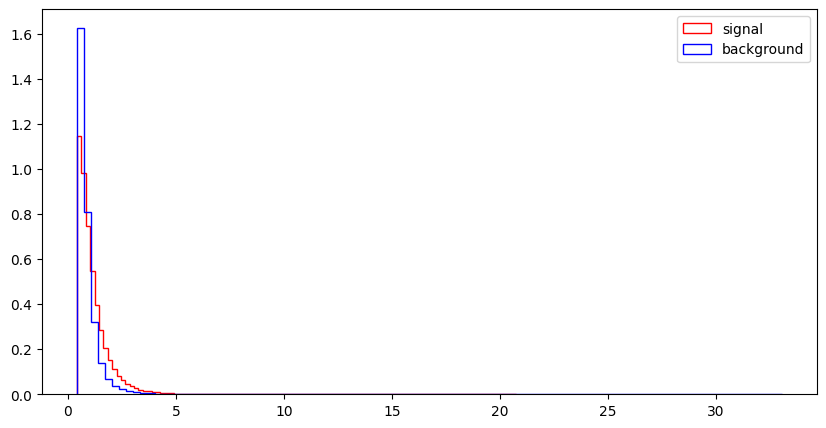

l_2_eta


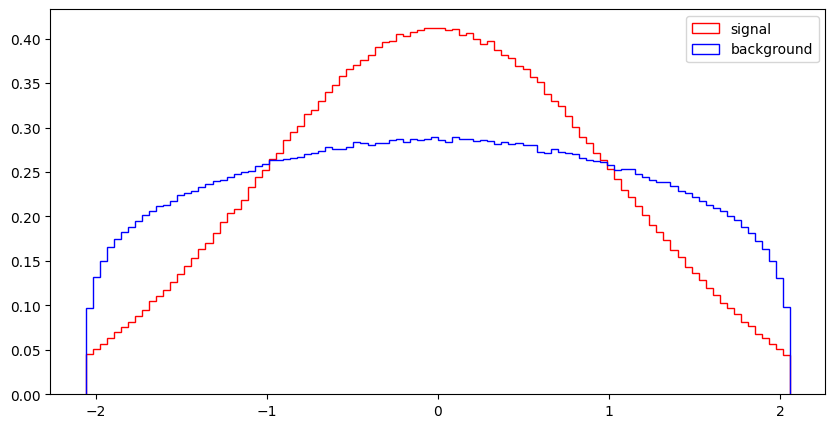

l_2_phi


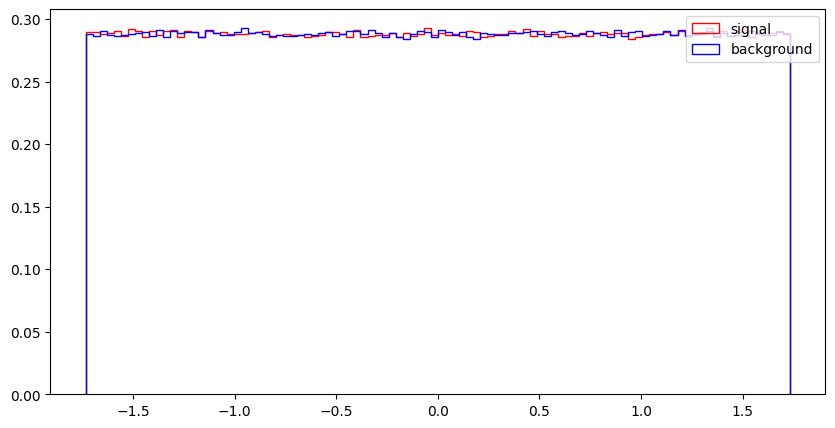

MET


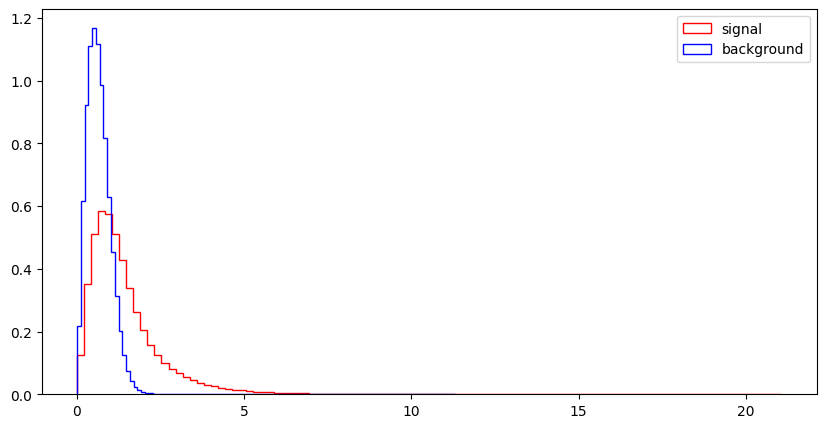

MET_phi


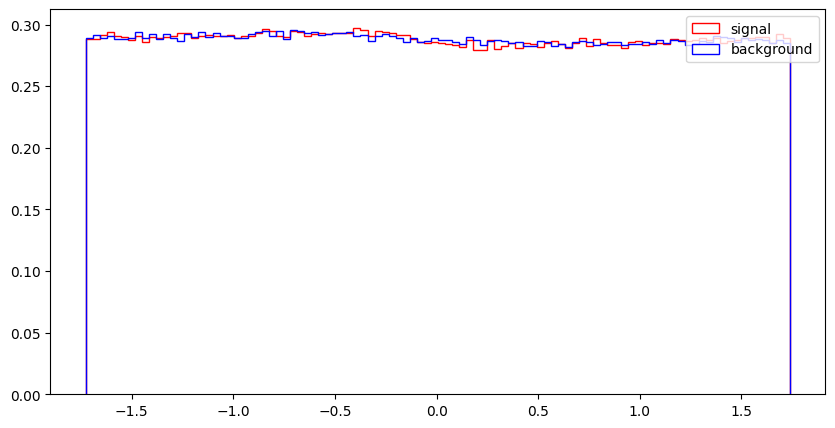

MET_rel


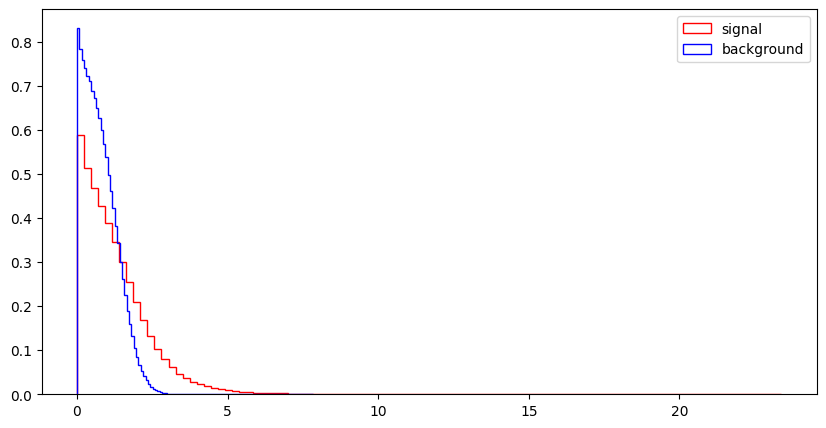

axial_MET


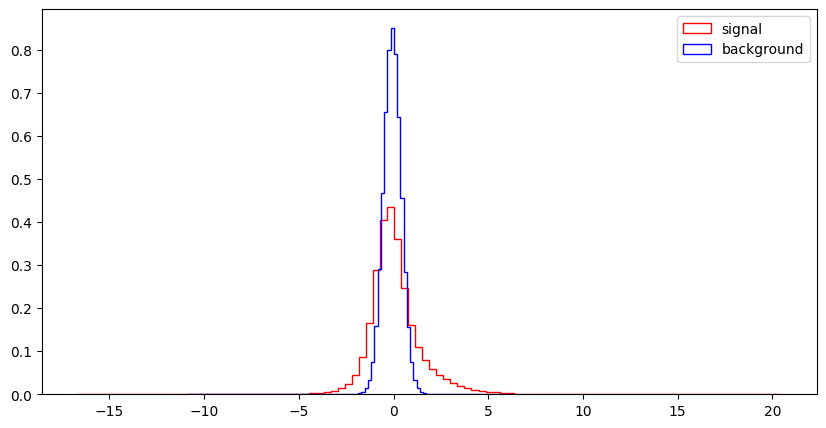

M_R


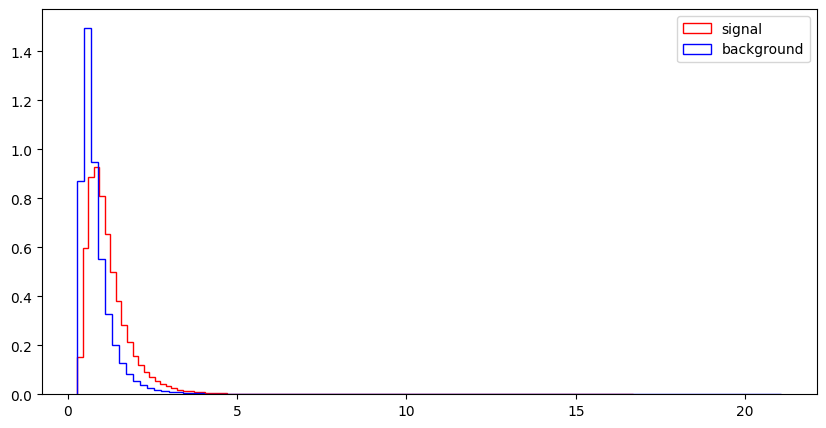

M_TR_2


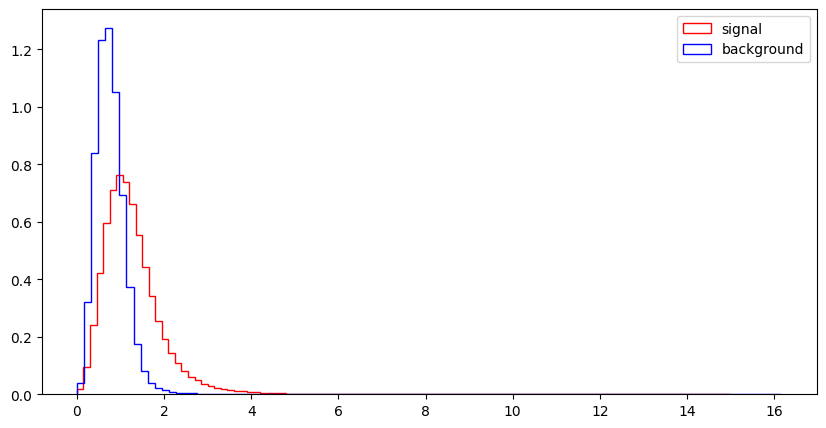

R


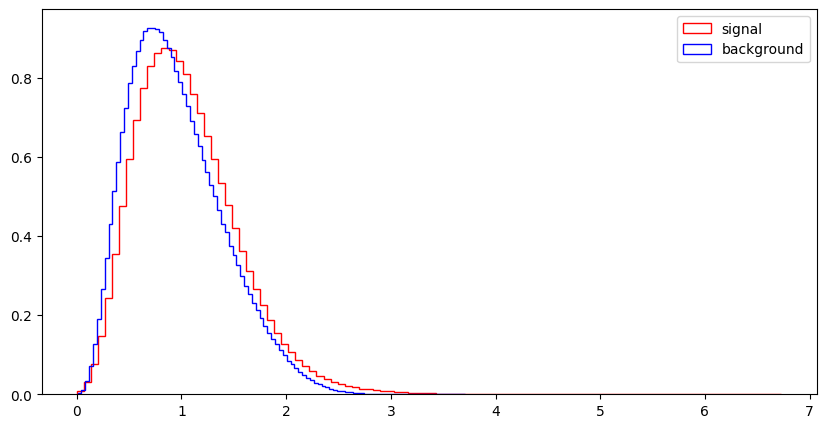

MT2


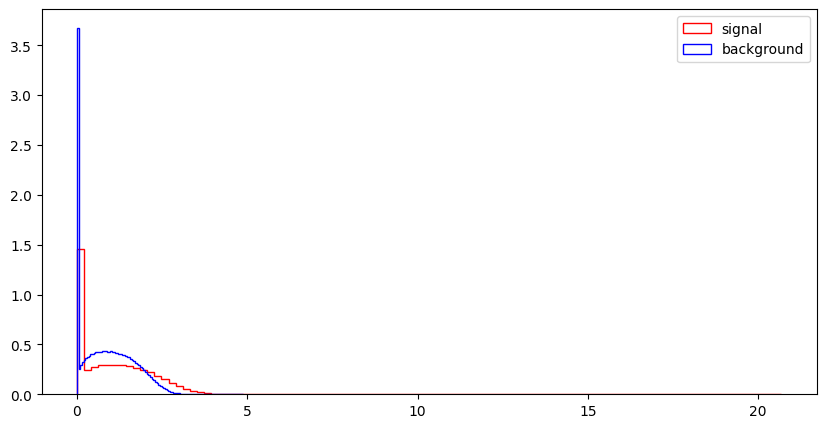

S_R


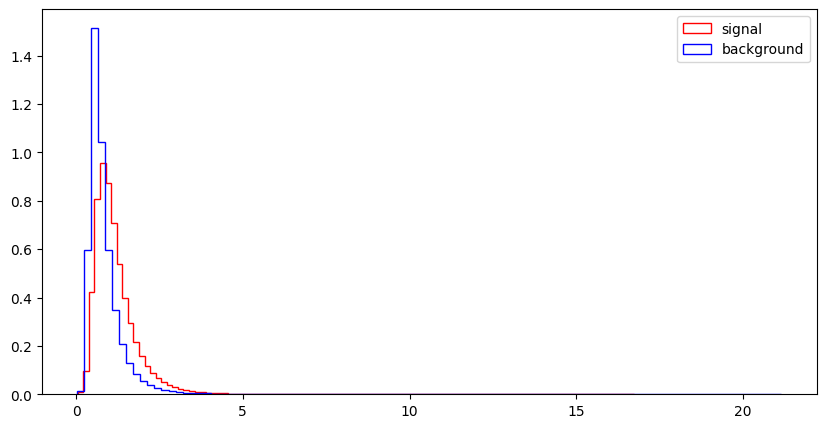

M_Delta_R


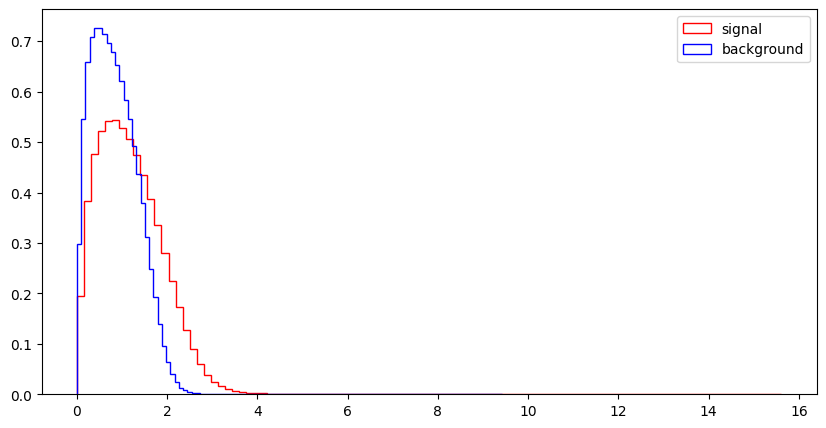

dPhi_r_b


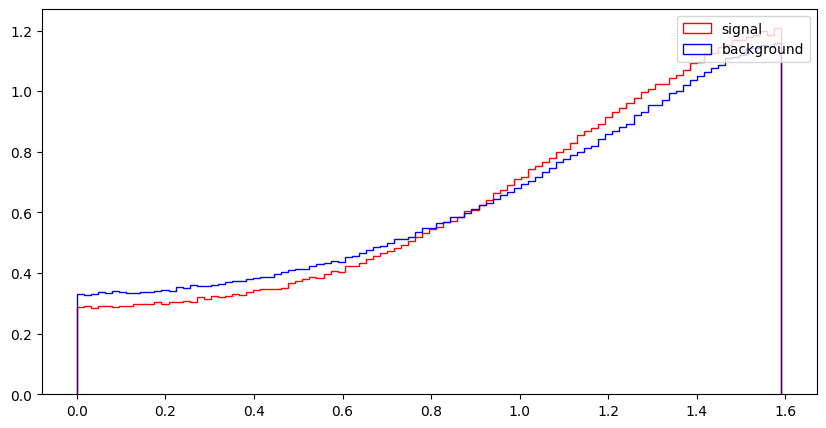

cos_theta_r1


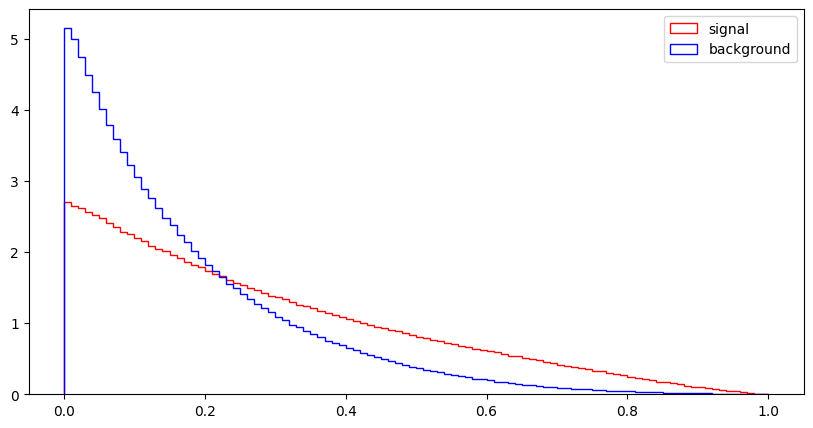

In [12]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

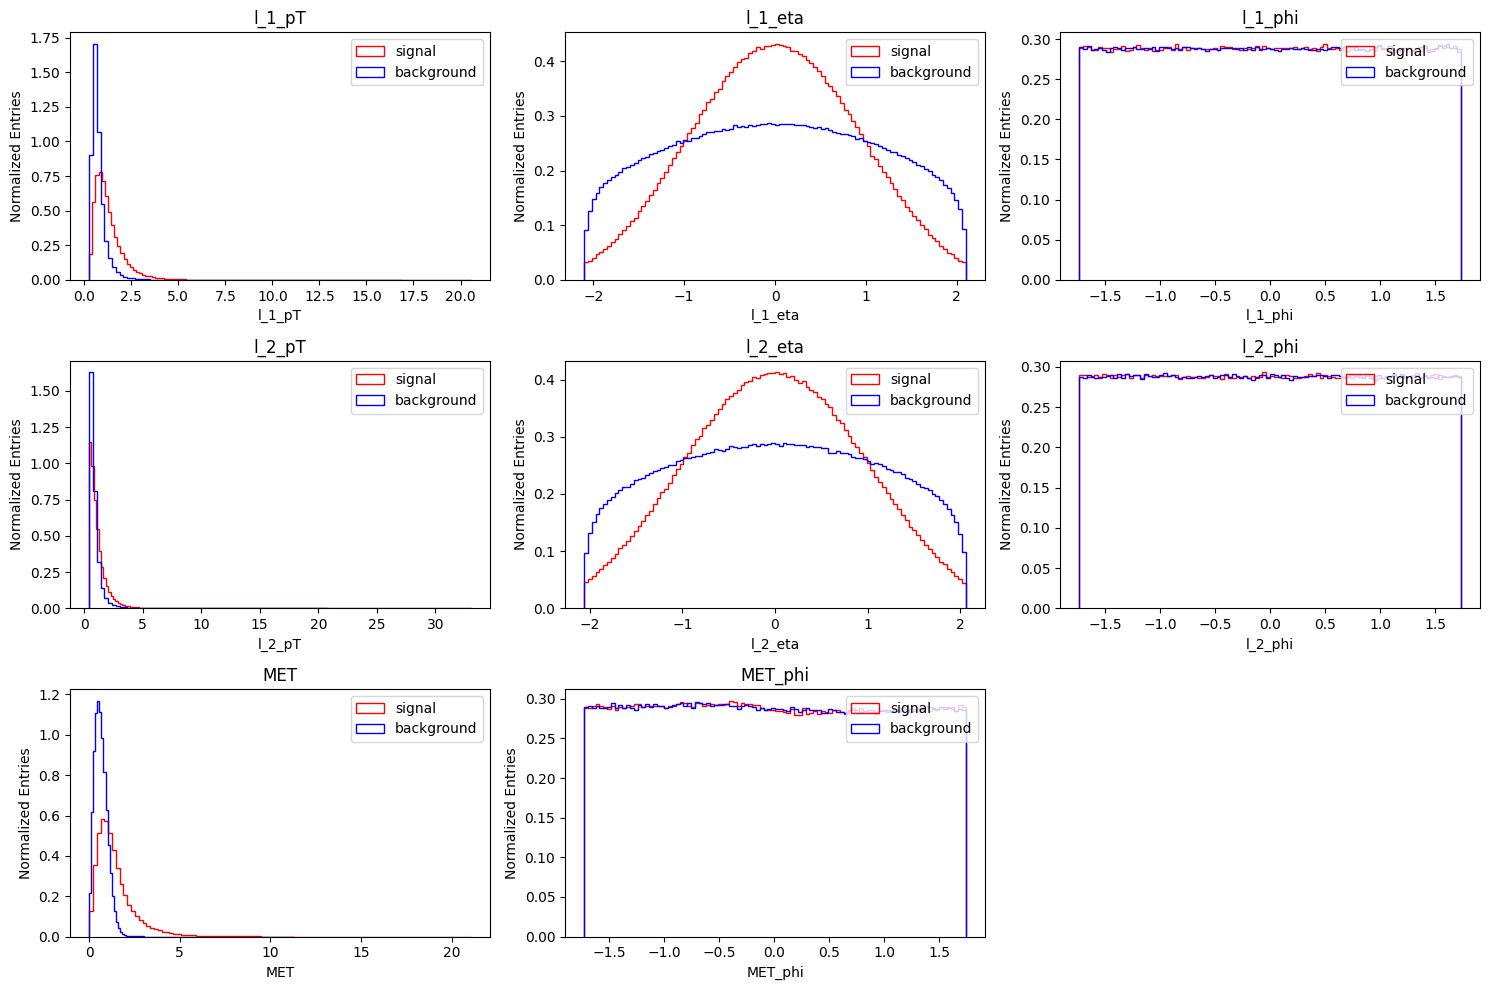

In [13]:
# Create a large figure (this is ONE window that will hold many plots)
plt.figure(figsize=(15,10))

# This keeps track of which subplot position we are on
i = 1

# Loop over each raw variable (these were already defined earlier)
for var in RawNames:
    
    # Create a subplot in a 3x3 grid at position i
    # (3 rows, 3 columns, position i)
    plt.subplot(3,3,i)
    
    # Plot histogram for SIGNAL events (red)
    plt.hist(df_sig[var], 
             bins=100,              # number of bins
             density=True,          # normalize the histogram
             histtype="step",       # just draw the outline
             color="red", 
             label="signal")
    
    # Plot histogram for BACKGROUND events (blue)
    plt.hist(df_bkg[var], 
             bins=100, 
             density=True, 
             histtype="step", 
             color="blue", 
             label="background")
    
    # Add title (variable name)
    plt.title(var)
    
    # Label x-axis (what variable this is)
    plt.xlabel(var)
    
    # Label y-axis (normalized counts)
    plt.ylabel("Normalized Entries")
    
    # Show legend (signal vs background)
    plt.legend(loc='upper right')
    
    # Move to the next subplot position
    i = i + 1

# Automatically adjust spacing so plots don’t overlap
plt.tight_layout()

# Display the full figure
plt.show()

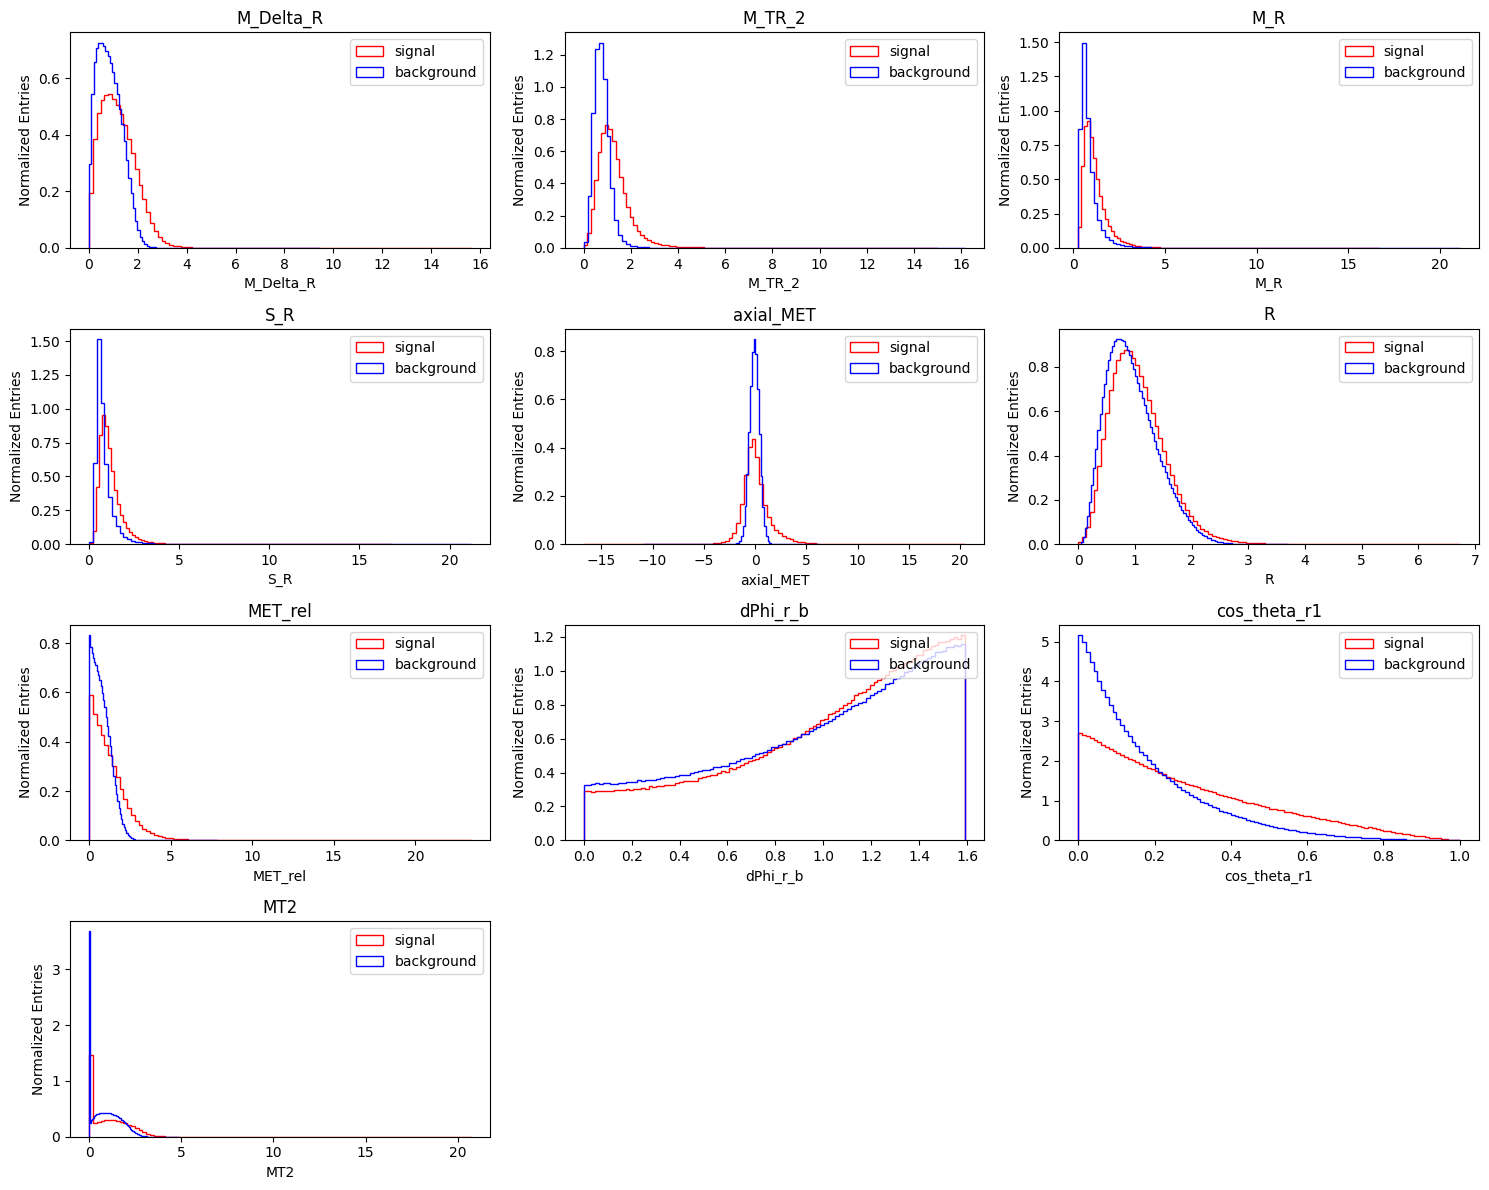

In [14]:
# Create a new figure for feature variables
plt.figure(figsize=(15,12))

# Start subplot counter again
i = 1

# Loop over each derived/feature variable
for var in FeatureNames:
    
    # Create a subplot in a 4x3 grid
    # (4 rows, 3 columns)
    plt.subplot(4,3,i)
    
    # Plot SIGNAL distribution
    plt.hist(df_sig[var], 
             bins=100, 
             density=True,
             histtype="step", 
             color="red", 
             label="signal")
    
    # Plot BACKGROUND distribution
    plt.hist(df_bkg[var], 
             bins=100, 
             density=True,
             histtype="step", 
             color="blue", 
             label="background")
    
    # Title = variable name
    plt.title(var)
    
    # Axis labels
    plt.xlabel(var)
    plt.ylabel("Normalized Entries")
    
    # Legend
    plt.legend(loc='upper right')
    
    # Move to next subplot
    i = i + 1

# Fix spacing
plt.tight_layout()

# Show the figure
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

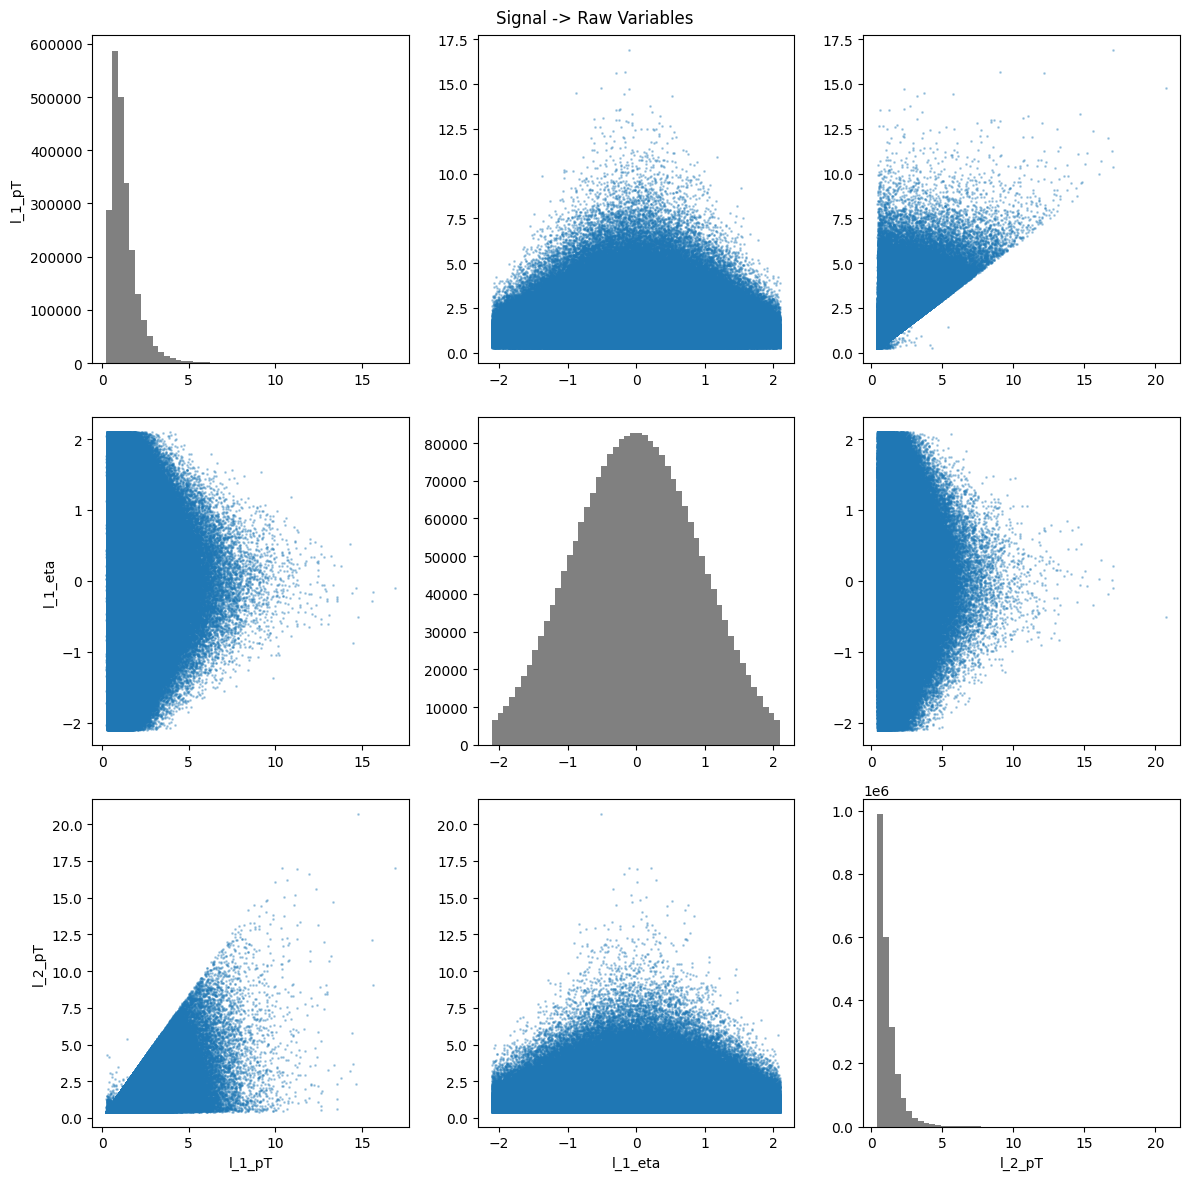

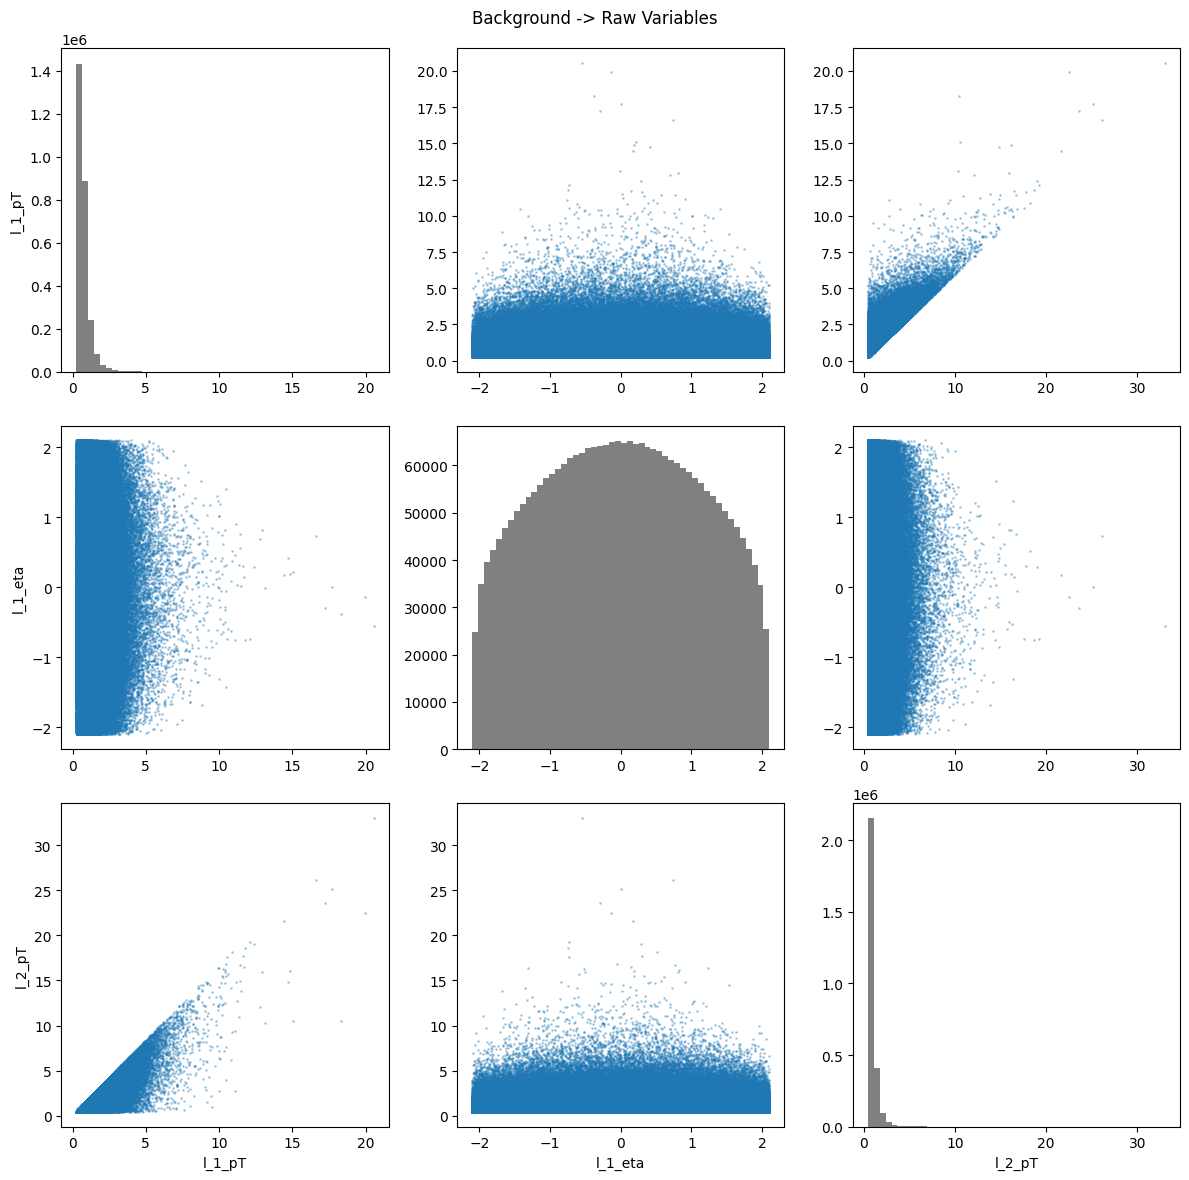

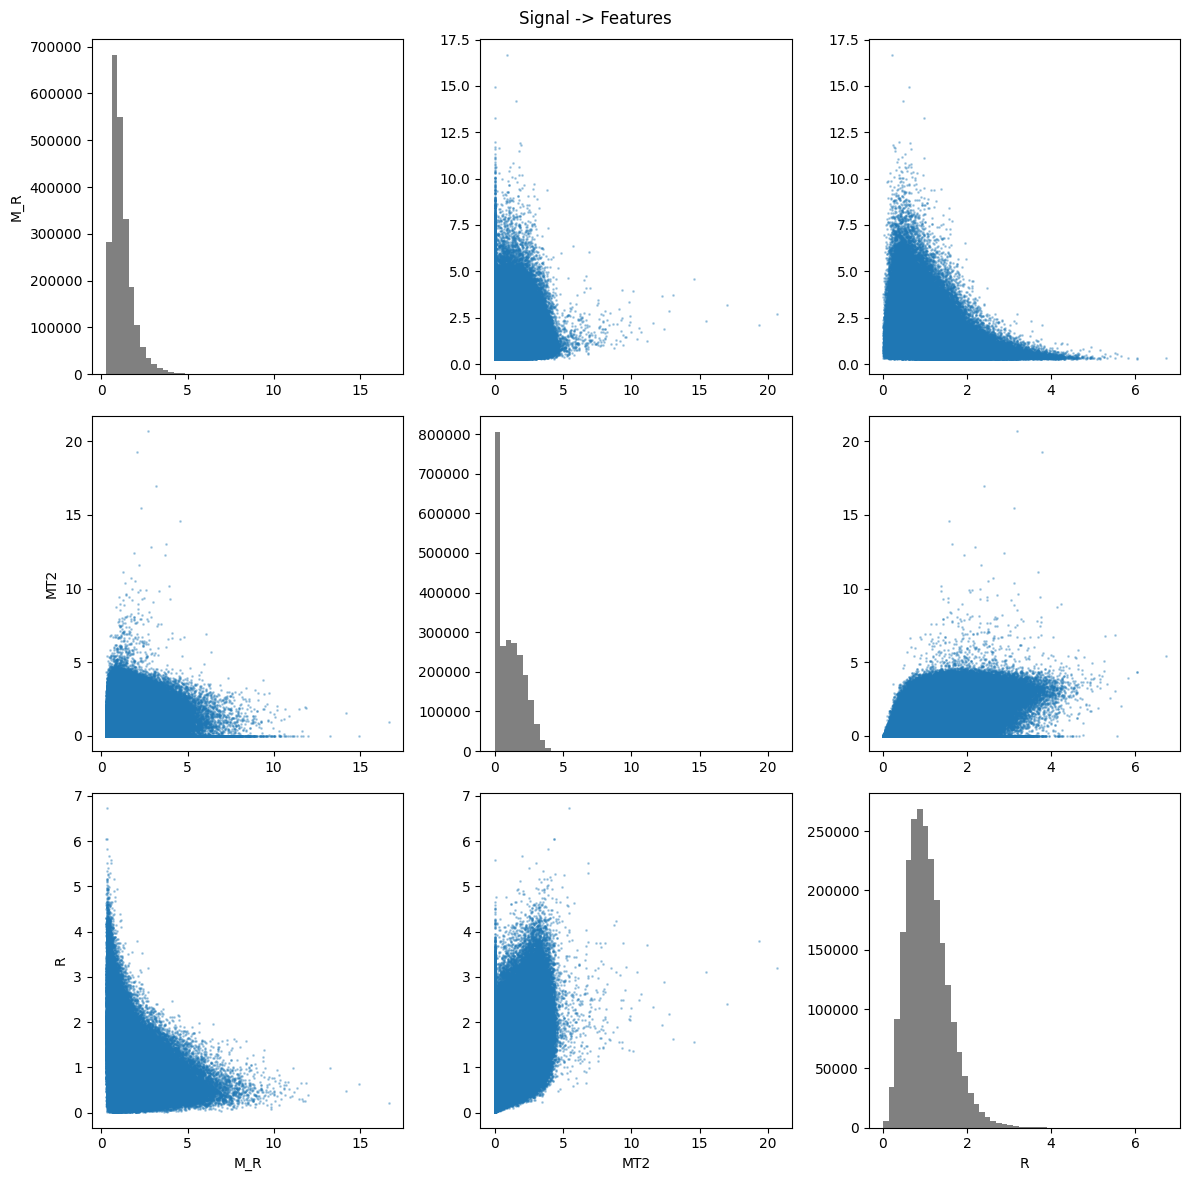

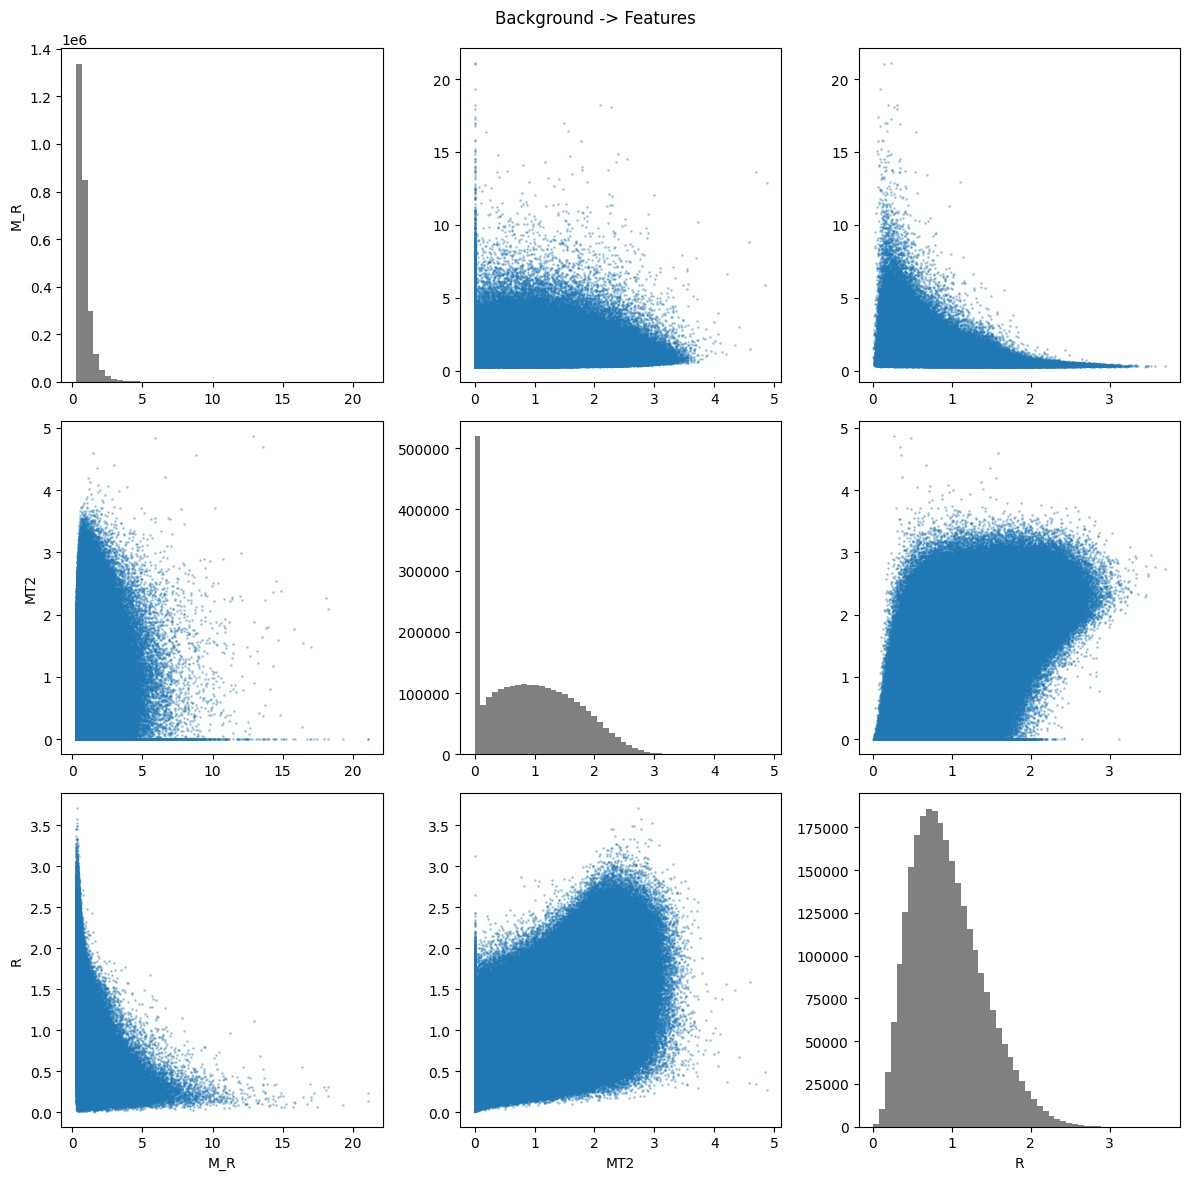

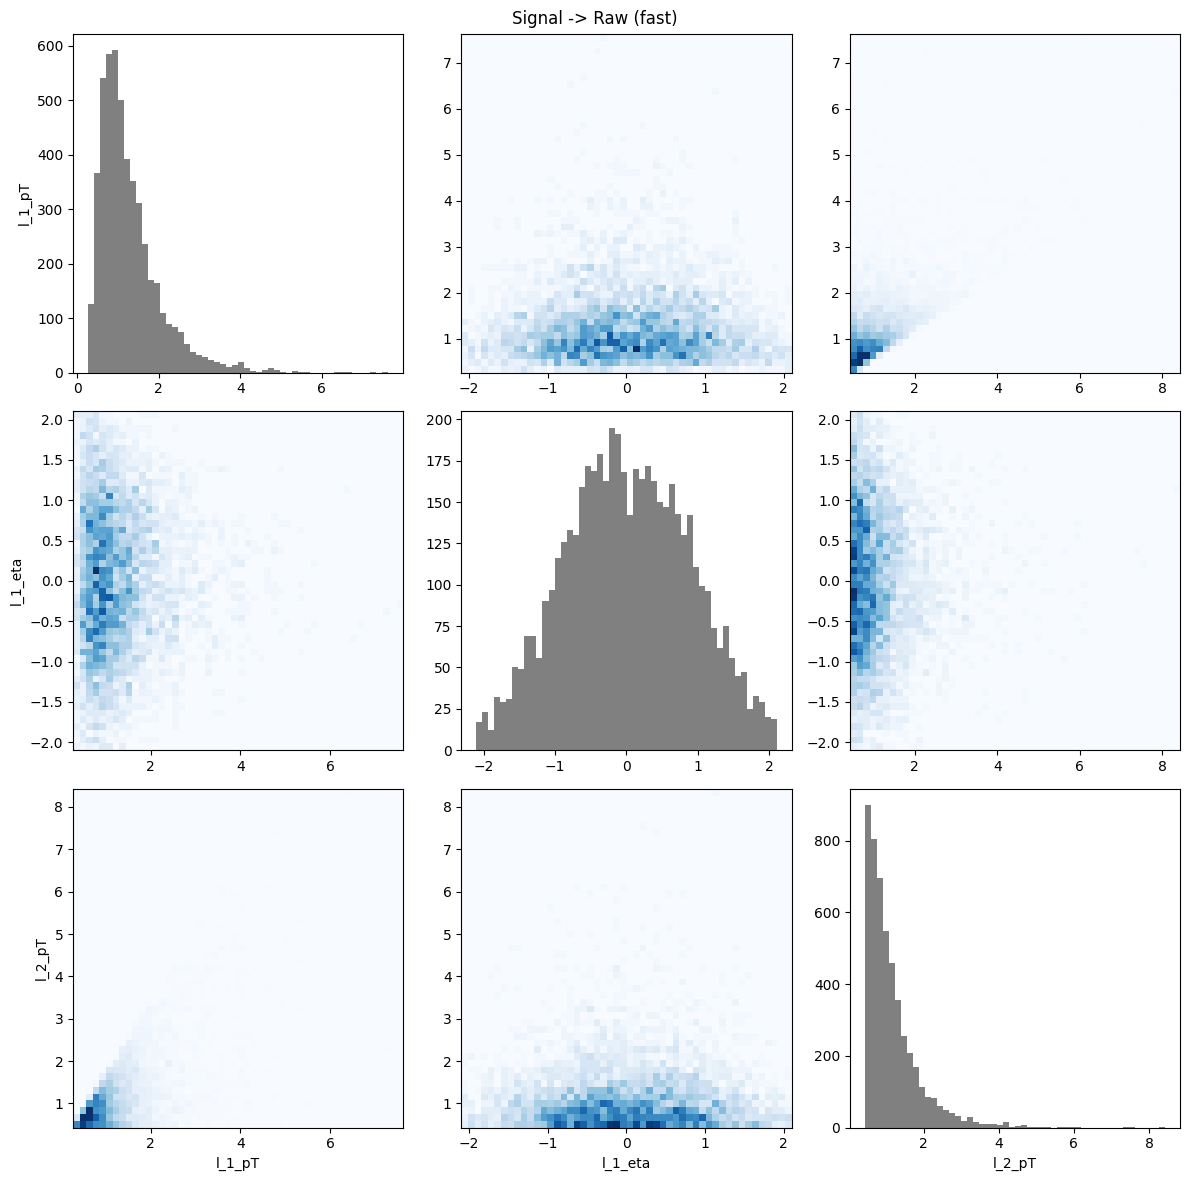

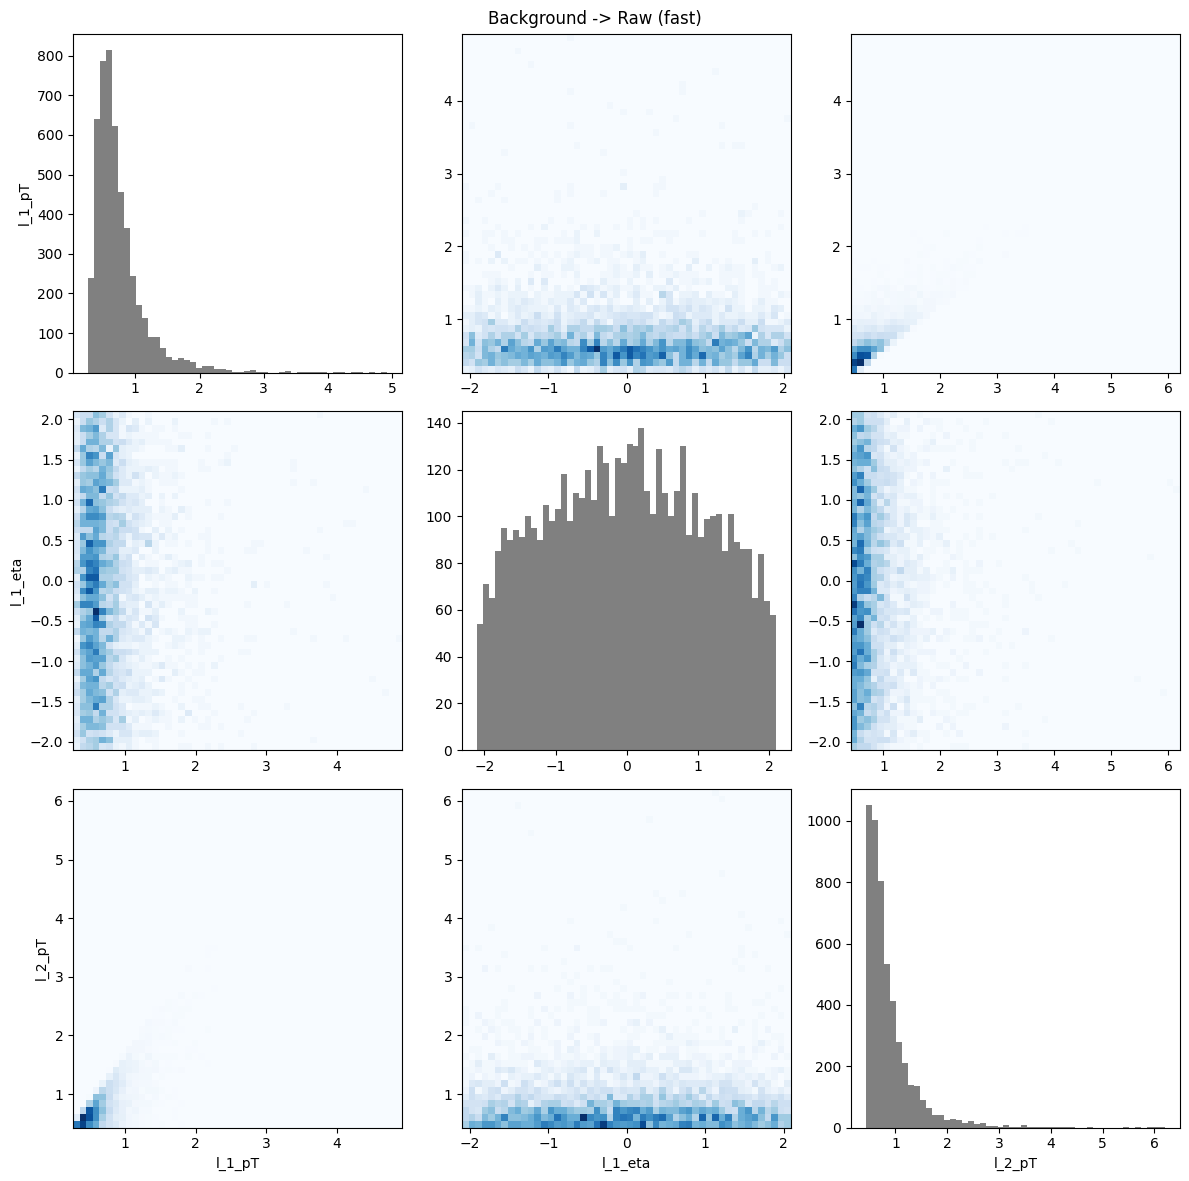

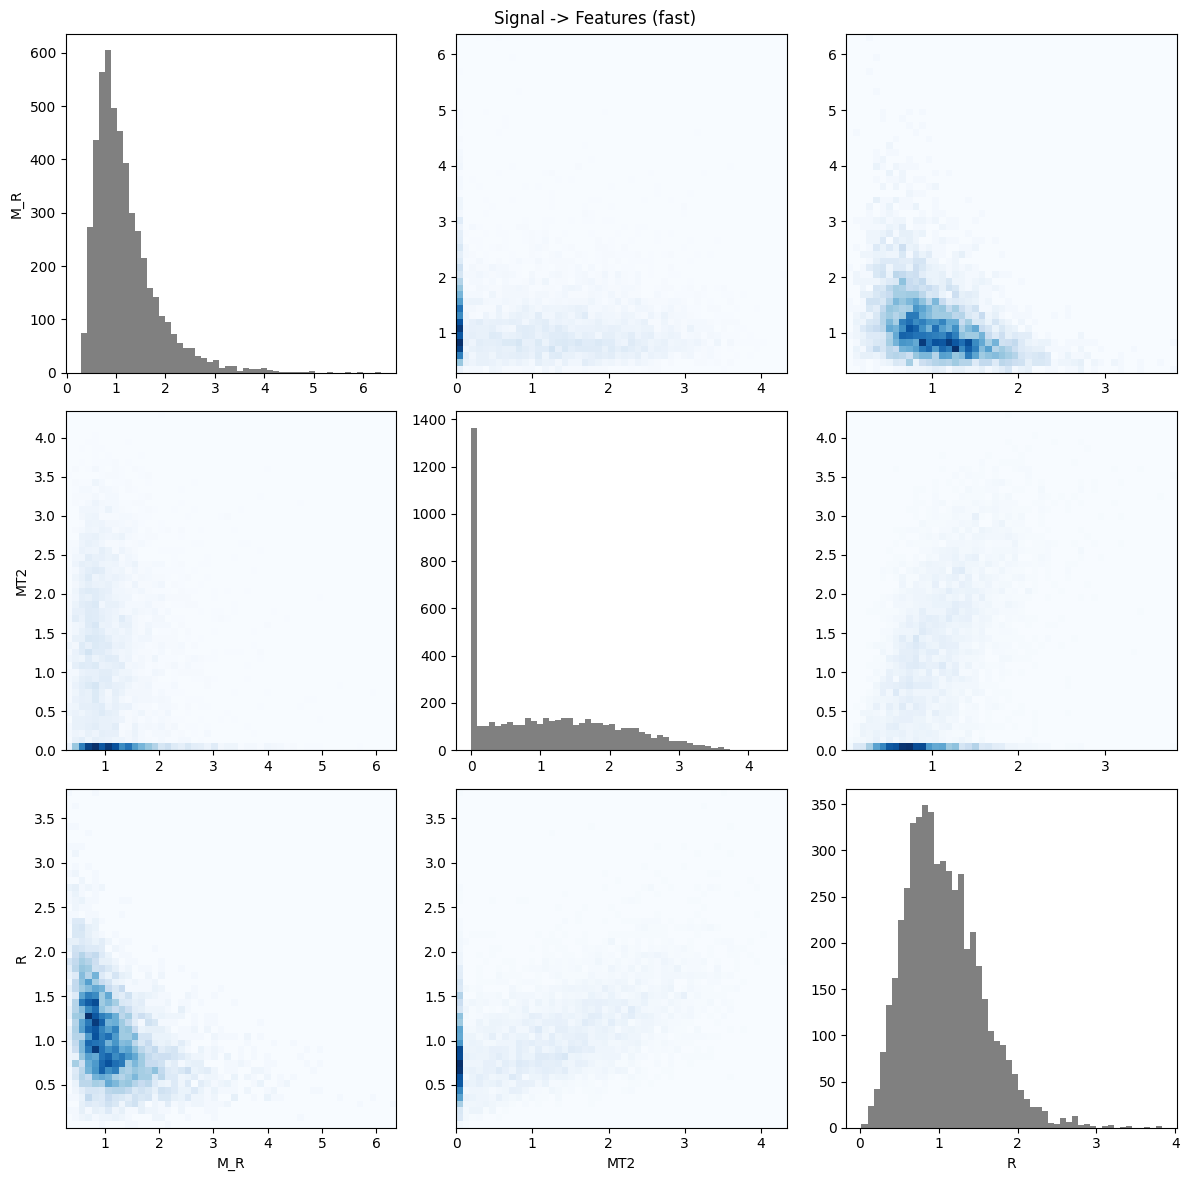

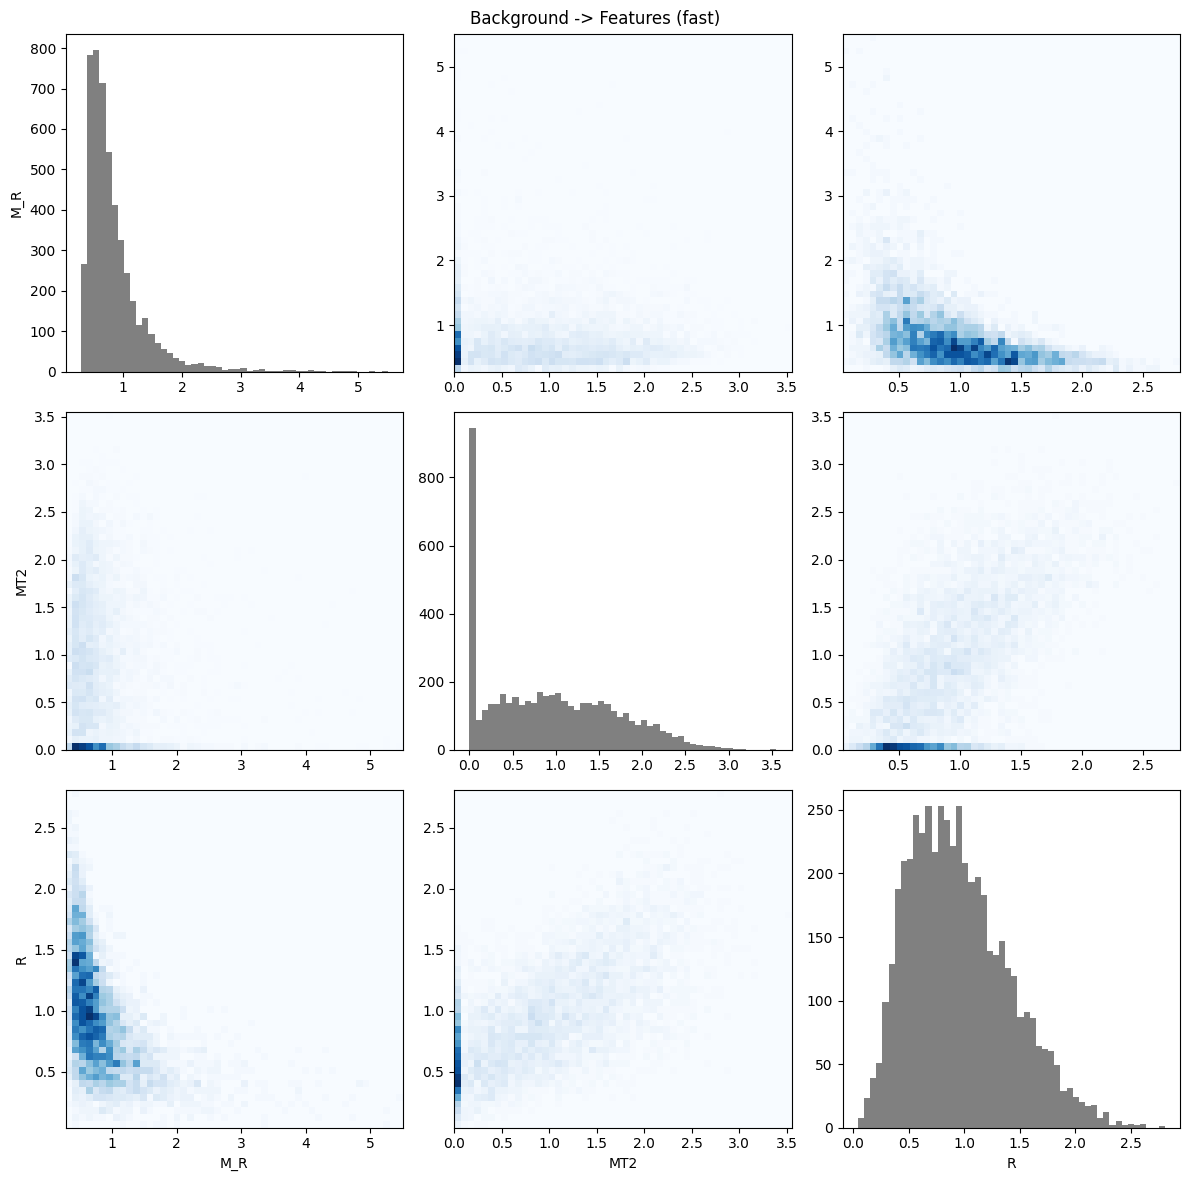

In [20]:
# Pair plots
def make_pair_plot(df, var_list, title, use_hist2d=False):

    import matplotlib.pyplot as plt

    # Number of variables to plot
    n = len(var_list)

    # Create a big figure for all subplots
    plt.figure(figsize=(12,12))

    # Counter to keep track of subplot position
    plot_number = 1

    # Loop over rows (y-axis)
    for i in range(n):

        # Loop over columns (x-axis)
        for j in range(n):

            # Create subplot at current position
            plt.subplot(n, n, plot_number)

            # Current variables for x and y axes
            xvar = var_list[j]
            yvar = var_list[i]

            # Diagonal -> histogram
            if i == j:
                plt.hist(df[xvar], bins=50, color='gray')

            # Off-diagonal -> scatter plot or 2D histogram
            else:
                if use_hist2d:
                    plt.hist2d(df[xvar], df[yvar], bins=50, cmap='Blues')
                else:
                    plt.scatter(df[xvar], df[yvar], s=1, alpha=0.3)

            # Only label outer edges for readability
            if i == n - 1:
                plt.xlabel(xvar)
            if j == 0:
                plt.ylabel(yvar)

            # Move to next subplot position
            plot_number = plot_number + 1

    # Add overall title
    plt.suptitle(title)

    # Adjust spacing so labels don’t overlap
    plt.tight_layout()

    # Show the figure
    plt.show()


# Small subset of variables for faster plotting
raw_subset = ["l_1_pT", "l_1_eta", "l_2_pT"]
feature_subset = ["M_R", "MT2", "R"]

# ------------------------------------------------------
# Part A: Pair plots with full dataset
make_pair_plot(df_sig, raw_subset, "Signal -> Raw Variables")
make_pair_plot(df_bkg, raw_subset, "Background -> Raw Variables")
make_pair_plot(df_sig, feature_subset, "Signal -> Features")
make_pair_plot(df_bkg, feature_subset, "Background -> Features")

# -------------------------------------------------------
# Part B: Speed up using smaller samples + 2D histograms
df_sig_small = df_sig.sample(n=5000)
df_bkg_small = df_bkg.sample(n=5000)

make_pair_plot(df_sig_small, raw_subset, "Signal -> Raw (fast)", use_hist2d=True)
make_pair_plot(df_bkg_small, raw_subset, "Background -> Raw (fast)", use_hist2d=True)
make_pair_plot(df_sig_small, feature_subset, "Signal -> Features (fast)", use_hist2d=True)
make_pair_plot(df_bkg_small, feature_subset, "Background -> Features (fast)", use_hist2d=True)

In [15]:
# Part C
# The derived features such as MT2, M_R, and R show better separation between signal and background. 
# The raw variables have more overlap, while the engineered features show clearer differences in both their distributions and correlations.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [21]:
# Part A: installed tabulate via terminal

# Part B: Compute covariance and correlation matrices
import numpy as np

# Covariance and correlation for all variables (skip first column = signal)
cov_matrix = np.cov(df[VarNames[1:]].values.T)  # Transpose so features are rows
corr_matrix = np.corrcoef(df[VarNames[1:]].values.T)

# Covariance and correlation for low-level (raw) variables
cov_raw = np.cov(df[RawNames].values.T)
corr_raw = np.corrcoef(df[RawNames].values.T)

# Covariance and correlation for high-level (feature) variables
cov_feat = np.cov(df[FeatureNames].values.T)
corr_feat = np.corrcoef(df[FeatureNames].values.T)

# ----------------------------------------
# Part C: Use tabulate to display matrices
from IPython.display import HTML, display
import tabulate

# Function to display a matrix as a table
def display_matrix(matrix, labels, title):
    # Round numbers to 3 decimal places
    rounded = np.round(matrix, 3)

    # Build table as a list of lists
    table = []
    for i in range(len(labels)):
        row = [labels[i]]  # First column is variable name
        for j in range(len(labels)):
            row.append(rounded[i,j])
        table.append(row)

    # Display table using tabulate
    display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Var"] + labels)))

    # Print a title above the table
    print(title)

# Display covariance and correlation for raw variables
display_matrix(cov_raw, RawNames, "Covariance Matrix -> Raw Variables")
display_matrix(corr_raw, RawNames, "Correlation Matrix -> Raw Variables")

# Display covariance and correlation for feature variables
display_matrix(cov_feat, FeatureNames, "Covariance Matrix -> Features")
display_matrix(corr_feat, FeatureNames, "Correlation Matrix -> Features")

# ----------------------------------------
# Part D: Wrap into a reusable function
def show_cov_corr(df, variable_list, title_prefix):
    # Compute covariance and correlation
    matrix_cov = np.cov(df[variable_list].values.T)
    matrix_corr = np.corrcoef(df[variable_list].values.T)

    # Show the tables
    display_matrix(matrix_cov, variable_list, title_prefix + " Covariance")
    display_matrix(matrix_corr, variable_list, title_prefix + " Correlation")

# Test Code:
show_cov_corr(df, RawNames, "Raw Variables ->")
show_cov_corr(df, FeatureNames, "Features ->")

Var,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


Covariance Matrix -> Raw Variables


Var,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


Correlation Matrix -> Raw Variables


Var,M_Delta_R,M_TR_2,M_R,S_R,axial_MET,R,MET_rel,dPhi_r_b,cos_theta_r1,MT2
M_Delta_R,0.389,0.242,0.074,0.096,-0.234,0.166,0.416,0.042,0.039,0.433
M_TR_2,0.242,0.341,0.212,0.23,-0.189,0.104,0.303,0.058,0.052,0.189
M_R,0.074,0.212,0.395,0.383,0.015,-0.113,0.044,-0.029,-0.014,-0.037
S_R,0.096,0.23,0.383,0.385,-0.043,-0.083,0.082,-0.004,-0.01,-0.011
axial_MET,-0.234,-0.189,0.015,-0.043,1.003,-0.182,-0.125,-0.026,-0.054,-0.46
R,0.166,0.104,-0.113,-0.083,-0.182,0.222,0.25,0.087,0.058,0.232
MET_rel,0.416,0.303,0.044,0.082,-0.125,0.25,0.792,0.147,0.056,0.41
dPhi_r_b,0.042,0.058,-0.029,-0.004,-0.026,0.087,0.147,0.19,0.009,0.021
cos_theta_r1,0.039,0.052,-0.014,-0.01,-0.054,0.058,0.056,0.009,0.039,0.045
MT2,0.433,0.189,-0.037,-0.011,-0.46,0.232,0.41,0.021,0.045,0.738


...

Raw Variables -> Correlation


Var,M_Delta_R,M_TR_2,M_R,S_R,axial_MET,R,MET_rel,dPhi_r_b,cos_theta_r1,MT2
M_Delta_R,0.389,0.242,0.074,0.096,-0.234,0.166,0.416,0.042,0.039,0.433
M_TR_2,0.242,0.341,0.212,0.23,-0.189,0.104,0.303,0.058,0.052,0.189
M_R,0.074,0.212,0.395,0.383,0.015,-0.113,0.044,-0.029,-0.014,-0.037
S_R,0.096,0.23,0.383,0.385,-0.043,-0.083,0.082,-0.004,-0.01,-0.011
axial_MET,-0.234,-0.189,0.015,-0.043,1.003,-0.182,-0.125,-0.026,-0.054,-0.46
R,0.166,0.104,-0.113,-0.083,-0.182,0.222,0.25,0.087,0.058,0.232
MET_rel,0.416,0.303,0.044,0.082,-0.125,0.25,0.792,0.147,0.056,0.41
dPhi_r_b,0.042,0.058,-0.029,-0.004,-0.026,0.087,0.147,0.19,0.009,0.021
cos_theta_r1,0.039,0.052,-0.014,-0.01,-0.054,0.058,0.056,0.009,0.039,0.045
MT2,0.433,0.189,-0.037,-0.011,-0.46,0.232,0.41,0.021,0.045,0.738


Features -> Covariance


Var,M_Delta_R,M_TR_2,M_R,S_R,axial_MET,R,MET_rel,dPhi_r_b,cos_theta_r1,MT2
M_Delta_R,1,0.666,0.189,0.248,-0.375,0.564,0.749,0.156,0.319,0.808
M_TR_2,0.666,1,0.578,0.636,-0.323,0.38,0.583,0.228,0.451,0.378
M_R,0.189,0.578,1,0.981,0.024,-0.381,0.078,-0.106,-0.115,-0.068
S_R,0.248,0.636,0.981,1,-0.07,-0.285,0.149,-0.013,-0.084,-0.021
axial_MET,-0.375,-0.323,0.024,-0.07,1,-0.385,-0.141,-0.06,-0.274,-0.535
R,0.564,0.38,-0.381,-0.285,-0.385,1,0.595,0.424,0.627,0.574
MET_rel,0.749,0.583,0.078,0.149,-0.141,0.595,1,0.378,0.317,0.536
dPhi_r_b,0.156,0.228,-0.106,-0.013,-0.06,0.424,0.378,1,0.106,0.056
cos_theta_r1,0.319,0.451,-0.115,-0.084,-0.274,0.627,0.317,0.106,1,0.263
MT2,0.808,0.378,-0.068,-0.021,-0.535,0.574,0.536,0.056,0.263,1


Features -> Correlation


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 